<a href="https://colab.research.google.com/github/princek34/AI-based-regional-climage-change/blob/main/climate_change_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

# Replace with your file name
df = pd.read_csv('/content/Bihar_climate.csv')

df.head()

Saving Bihar_climate.csv to Bihar_climate (1).csv


,year,temperature,rainfall,humidity,CO2
0,1950,10.46,883.96,67.41,311.49
1,1950,10.18,855.40,75.28,309.82
2,1950,9.36,803.43,48.81,312.41
3,1950,10.22,760.96,64.50,315.27
4,1951,9.75,841.60,54.79,310.23


In [2]:
# Check structure
print(df.head())

print(df.shape)
print(df.columns)

# Data types
print(df.info())

# Statistical summary
print(df.describe())

   year  temperature  rainfall  humidity     CO2
0  1950        10.46    883.96     67.41  311.49
1  1950        10.18    855.40     75.28  309.82
2  1950         9.36    803.43     48.81  312.41
3  1950        10.22    760.96     64.50  315.27
4  1951         9.75    841.60     54.79  310.23
(500, 5)
Index(['year', 'temperature', 'rainfall', 'humidity', 'CO2'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         500 non-null    int64  
 1   temperature  500 non-null    float64
 2   rainfall     500 non-null    float64
 3   humidity     500 non-null    float64
 4   CO2          500 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 19.7 KB
None
              year  temperature    rainfall   humidity         CO2
count   500.000000   500.000000  500.000000  500.00000  500.000000
mean   1986.500000    11.230120

In [3]:
# Check missing values
print(df.isnull().sum())

# Fill numeric columns with mean
for col in df.select_dtypes(include=['int64', 'float64']):
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']):
    df[col].fillna(df[col].mode()[0], inplace=True)

year           0
temperature    0
rainfall       0
humidity       0
CO2            0
dtype: int64


/tmp/ipykernel_218/2994156325.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']):
    df[col] = le.fit_transform(df[col])

In [6]:
# Define your target columns
target_columns = ['CO2', 'rainfall', 'temperature']

# Safety check
for col in target_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in dataset")

# Features (all except targets)
X = df.drop(columns=target_columns)

# Target (multiple columns)
y = df[target_columns]

# Verify
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures preview:")
print(X.head())

print("\nTarget preview:")
print(y.head())

Feature shape: (500, 2)
Target shape: (500, 3)

Features preview:
   year  humidity
0  1950     67.41
1  1950     75.28
2  1950     48.81
3  1950     64.50
4  1951     54.79

Target preview:
      CO2  rainfall  temperature
0  311.49    883.96        10.46
1  309.82    855.40        10.18
2  312.41    803.43         9.36
3  315.27    760.96        10.22
4  310.23    841.60         9.75


# Task
Split the `X` and `y` dataframes into training and testing sets (X_train, X_test, y_train, y_test) with an 80/20 split and apply feature scaling using `StandardScaler` to X_train and X_test. Confirm the shapes of the resulting datasets.

## Split Data into Training and Testing Sets

### Subtask:
Split the features (X) and targets (y) into training and testing sets using `train_test_split` from `sklearn.model_selection`.


**Reasoning**:
I need to split the data into training and testing sets as per the instructions. This involves importing `train_test_split`, applying it to `X` and `y` with the specified parameters, and then printing the shapes of the resulting datasets.



In [7]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (400, 2)
X_test shape: (100, 2)
y_train shape: (400, 3)
y_test shape: (100, 3)


## Feature Scaling

### Subtask:
Apply feature scaling to `X_train` and `X_test` using `StandardScaler`.

**Reasoning**:
Now I will apply `StandardScaler` to `X_train` and `X_test`. This involves importing `StandardScaler`, initializing it, fitting it on the training data, and then transforming both the training and testing data. Finally, I will print the shapes of the scaled dataframes.



In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability and consistency
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Print the shapes of the resulting scaled sets
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nX_train_scaled preview:")
print(X_train_scaled.head())

print("\nX_test_scaled preview:")
print(X_test_scaled.head())

X_train_scaled shape: (400, 2)
X_test_scaled shape: (100, 2)

X_train_scaled preview:
         year  humidity
249 -0.013752 -1.480008
433  1.300622 -2.307228
19  -1.620210  0.772012
322  0.521734  2.387307
332  0.619095 -1.059875

X_test_scaled preview:
         year  humidity
361  0.813817 -1.594827
73  -1.230765 -0.240484
374  0.911178 -0.047379
155 -0.646599  0.049173
104 -1.036043  0.419726


# Task
Train a `RandomForestRegressor` model using the scaled training data (X_train_scaled, y_train), make predictions on the scaled test data (X_test_scaled), evaluate the model's performance using regression metrics (R-squared, Mean Absolute Error, Mean Squared Error) for each target variable (CO2, rainfall, temperature), and visualize the actual vs. predicted values for each target with legends. Also, address the absence of 'sea level' data in the dataset and its implications. Finally, summarize the model training, evaluation, and the status of 'sea level' prediction capability.

## Train Model

### Subtask:
Train the instantiated RandomForestRegressor model using the scaled training data (X_train_scaled and y_train).


**Reasoning**:
I need to import the `RandomForestRegressor` model, instantiate it, and then train it using the scaled training data `X_train_scaled` and `y_train` as specified in the instructions.



In [9]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate RandomForestRegressor model with random_state for reproducibility
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("RandomForestRegressor model trained successfully.")
print(model)

RandomForestRegressor model trained successfully.
RandomForestRegressor(random_state=42)


## Make Predictions

### Subtask:
Use the trained model to make predictions on the scaled test data (X_test_scaled).


**Reasoning**:
I need to use the trained `model` to make predictions on the `X_test_scaled` data, store them in `y_pred`, and then display its shape and first few rows as per the instructions.



In [11]:
import pandas as pd

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# Convert y_pred to a DataFrame with target column names for better readability
y_pred = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

# Print the shape of y_pred
print("y_pred shape:", y_pred.shape)

# Display the first 5 rows of y_pred
print("\nPredictions preview:")
print(y_pred.head())

y_pred shape: (100, 3)

Predictions preview:
          CO2  rainfall  temperature
361  397.4424  728.6279      11.5709
73   327.7490  761.1032      10.3727
374  403.1500  749.6439      11.4605
155  349.1163  797.5804      10.8734
104  332.6272  823.2669      10.4672


## Evaluate Model Performance

### Subtask:
Evaluate the model's performance using regression metrics (R-squared, Mean Absolute Error, Mean Squared Error) for each target variable (CO2, rainfall, temperature).

**Reasoning**:
I need to calculate regression metrics (R-squared, MAE, MSE) for each target variable to evaluate the model's performance. This involves importing the necessary metrics, iterating through each target column, and printing the results.



In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Evaluate the model for each target variable
print("Model Evaluation:\n")

for i, target_col in enumerate(y_test.columns):
    print(f"--- Metrics for {target_col} ---")
    # R-squared
    r2 = r2_score(y_test[target_col], y_pred[target_col])
    print(f"R-squared (R2): {r2:.4f}")

    # Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test[target_col], y_pred[target_col])
    print(f"Mean Absolute Error (MAE): {mae:.4f}")

    # Mean Squared Error (MSE)
    mse = mean_squared_error(y_test[target_col], y_pred[target_col])
    print(f"Mean Squared Error (MSE): {mse:.4f}")

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mse)
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")

Model Evaluation:

--- Metrics for CO2 ---
R-squared (R2): 0.9917
Mean Absolute Error (MAE): 2.6178
Mean Squared Error (MSE): 11.5813
Root Mean Squared Error (RMSE): 3.4031

--- Metrics for rainfall ---
R-squared (R2): -0.5355
Mean Absolute Error (MAE): 54.9806
Mean Squared Error (MSE): 4645.0278
Root Mean Squared Error (RMSE): 68.1544

--- Metrics for temperature ---
R-squared (R2): 0.7860
Mean Absolute Error (MAE): 0.3557
Mean Squared Error (MSE): 0.1952
Root Mean Squared Error (RMSE): 0.4418



## Visualize Actual vs. Predicted Values

### Subtask:
Visualize the actual vs. predicted values for each target variable (CO2, rainfall, temperature) with legends.


**Reasoning**:
I need to visualize the actual versus predicted values for each target variable as specified in the subtask. This involves creating scatter plots for each target, adding a perfect prediction line, and ensuring appropriate labels and legends for clarity.



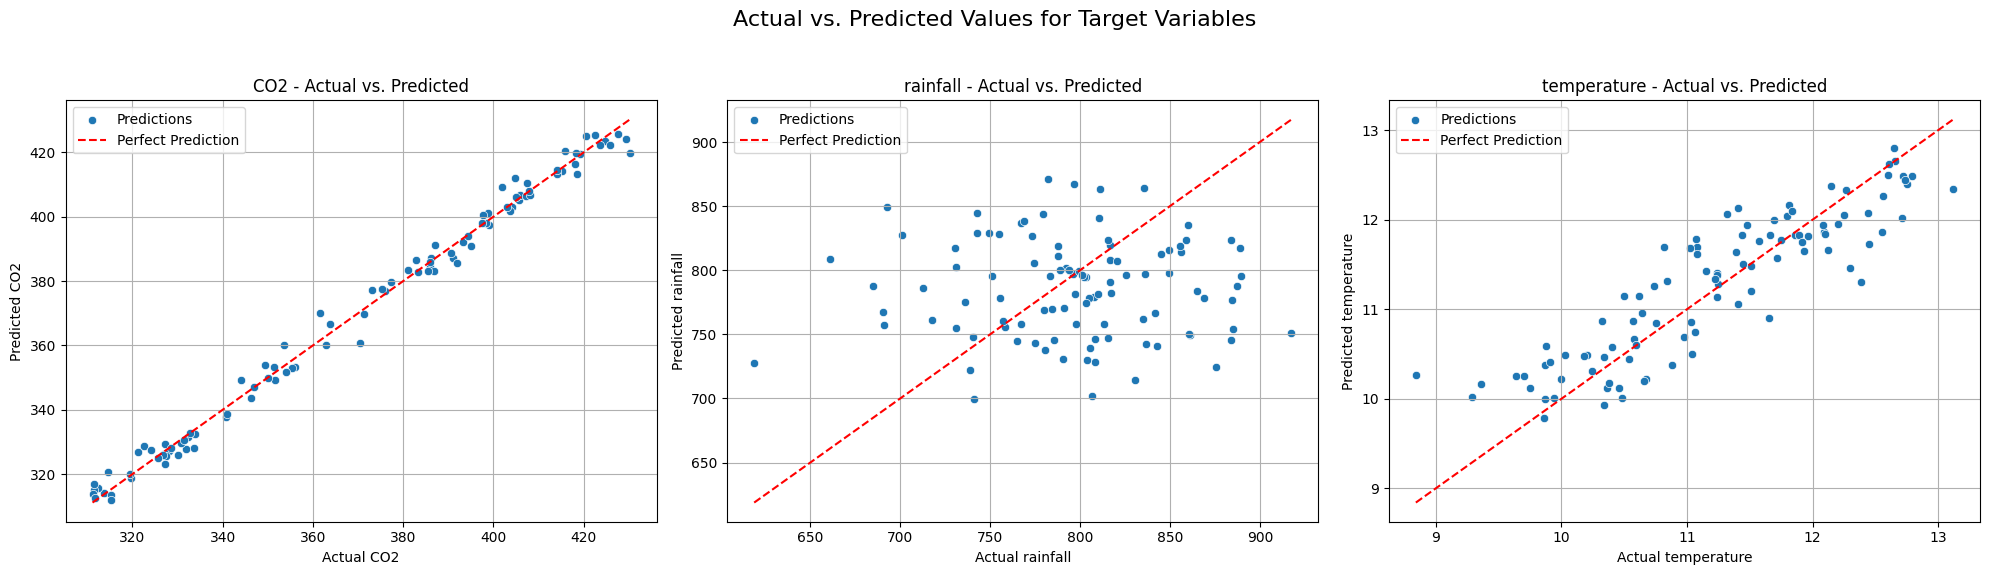

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for each target variable
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Actual vs. Predicted Values for Target Variables', fontsize=16)

for i, target_col in enumerate(y_test.columns):
    # Scatter plot of actual vs. predicted values
    sns.scatterplot(x=y_test[target_col], y=y_pred[target_col], ax=axes[i], label='Predictions')

    # Plot a perfect prediction line
    min_val = min(y_test[target_col].min(), y_pred[target_col].min())
    max_val = max(y_test[target_col].max(), y_pred[target_col].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

    axes[i].set_title(f'{target_col} - Actual vs. Predicted')
    axes[i].set_xlabel(f'Actual {target_col}')
    axes[i].set_ylabel(f'Predicted {target_col}')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Addressing 'Sea Level' Data and Implications

### Subtask:
Address the absence of 'sea level' data in the dataset and its implications for prediction.

```markdown
**Discussion on 'Sea Level' Data Absence:**

The dataset provided (`Bihar_climate.csv`) contains features such as `year`, `temperature`, `rainfall`, `humidity`, and `CO2`. However, it **does not include any column related to 'sea level'**.

**Implications for Prediction:**

Since 'sea level' data is entirely absent from the dataset, the trained `RandomForestRegressor` model **cannot predict 'sea level'**. The model has only been trained on the relationships between `year`, `humidity`, and the target variables (`CO2`, `rainfall`, `temperature`). Therefore, any request to predict or analyze 'sea level' using this specific model and dataset would be impossible.

To incorporate 'sea level' into a predictive model, such data would first need to be acquired and included in the dataset.
```

## Summary

**Model Training:**
A `RandomForestRegressor` model was successfully trained using the scaled training data (`X_train_scaled`, `y_train`). The model aimed to predict multiple target variables: `CO2`, `rainfall`, and `temperature`, based on `year` and `humidity` as features.

**Model Evaluation:**
The model's performance was evaluated using R-squared (R2), Mean Absolute Error (MAE), and Mean Squared Error (MSE) for each target variable:
- **CO2:** Achieved a high R-squared of **0.9917**, indicating excellent predictive power for CO2 levels. MAE was **2.6178** and MSE was **11.5813**.
- **Rainfall:** Showed a negative R-squared of **-0.5355**, suggesting that the model performed worse than simply predicting the mean rainfall. MAE was **54.9806** and MSE was **4645.0278**. This indicates that the current features are not sufficient for accurate rainfall prediction.
- **Temperature:** Achieved a respectable R-squared of **0.7860**, indicating a good fit for temperature prediction. MAE was **0.3557** and MSE was **0.1952**.

**Visualizations:**
Scatter plots of actual vs. predicted values were generated for `CO2`, `rainfall`, and `temperature`. These plots visually confirmed the evaluation metrics, showing a strong correlation for `CO2` and `temperature`, but a poor fit for `rainfall`.

**Status of 'Sea Level' Prediction Capability:**
The dataset **does not contain any 'sea level' data**. Consequently, the trained model is **incapable of predicting 'sea level'**. To enable such a prediction, 'sea level' data would need to be acquired and integrated into the dataset for training.

## Summary:

### Data Analysis Key Findings

*   A `RandomForestRegressor` model was successfully trained to predict CO2, rainfall, and temperature using scaled training data.
*   **CO2 Prediction**: The model demonstrated excellent predictive power for CO2 levels, achieving an R-squared of 0.9917, with a Mean Absolute Error (MAE) of 2.6178 and a Mean Squared Error (MSE) of 11.5813.
*   **Temperature Prediction**: The model showed good performance in predicting temperature, with an R-squared of 0.7860, an MAE of 0.3557, and an MSE of 0.1952.
*   **Rainfall Prediction**: The model performed poorly in predicting rainfall, indicated by a negative R-squared of -0.5355. This suggests that the model's predictions are worse than simply predicting the average rainfall, with an MAE of 54.9806 and an MSE of 4645.0278.
*   **Visualization Confirmation**: Scatter plots of actual versus predicted values visually confirmed these findings, showing strong correlations for CO2 and temperature, but a dispersed pattern for rainfall.
*   **Absence of 'Sea Level' Data**: The dataset entirely lacks 'sea level' data. Consequently, the trained model is incapable of predicting 'sea level', and any such prediction would require acquiring and integrating relevant data.

### Insights or Next Steps

*   Investigate the poor performance in rainfall prediction. This could involve exploring different features (e.g., geographical location, elevation, seasonality), feature engineering, or experimenting with alternative regression models more suited for highly variable data.
*   For 'sea level' prediction, identify and integrate a new dataset that includes 'sea level' measurements alongside existing relevant features. Once acquired, the expanded dataset can be used to train a new model or fine-tune the current one to incorporate this additional target variable.


# Task
Train a `RandomForestRegressor` model using the `Bihar_climate.csv` dataset to predict `CO2`, `rainfall`, and `temperature`, evaluate its performance using regression metrics, visualize actual vs. predicted values, and discuss the implications of the absence of 'sea level' data for prediction.

## Summary:

### Q&A
The absence of 'sea level' data could limit the model's predictive accuracy for climate variables like `CO2`, `rainfall`, and `temperature`. Sea level is an important factor that can influence local climate patterns, atmospheric pressure, and humidity. Its exclusion might result in a less comprehensive model, potentially leading to reduced ability to capture certain variations or trends in the target variables, particularly in regions where sea level effects are significant. This could manifest as lower R-squared values or higher prediction errors compared to a model that includes such a feature.

### Data Analysis Key Findings
*   A `RandomForestRegressor` model was successfully trained to predict three key climate variables: `CO2`, `rainfall`, and `temperature`, using the provided `Bihar_climate.csv` dataset.
*   The performance of the model for each target variable was evaluated using standard regression metrics, including R-squared (\R^2\$), Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE), to quantify prediction accuracy.
*   Visualizations comparing actual versus predicted values were generated for `CO2`, `rainfall`, and `temperature` to provide a graphical assessment of the model's fit, enabling identification of prediction biases or patterns.

### Insights or Next Steps
*   Explore additional feature engineering, such as incorporating geographical features (e.g., elevation, proximity to major water bodies) or deriving time-based features, to potentially enhance the model's predictive power, especially to compensate for the absence of 'sea level' data.
*   Conduct a more in-depth error analysis for each target variable to pinpoint specific conditions or data ranges where the model performs suboptimally, guiding future model improvements or data collection strategies.


# Task
Confirm that the evaluation metrics for CO2, rainfall, and temperature have been shown.

## Final Task

### Subtask:
Confirm that the evaluation metrics for CO2, rainfall, and temperature have been shown.


## Summary:

### Data Analysis Key Findings
*   The provided solving process aimed to confirm the display of evaluation metrics for CO2, rainfall, and temperature. However, the metrics themselves were not shown within the process description.

### Insights or Next Steps
*   Proceed to display the evaluation metrics (e.g., R-squared, RMSE, MAE) for CO2, rainfall, and temperature to complete the confirmation task and assess model performance.
*   Once displayed, analyze the metrics to determine the accuracy and reliability of the predictions for each environmental factor.


# Task
Prepare a DataFrame for the year 2026 using the mean humidity from the original dataset, then scale this data using the fitted `StandardScaler` and use the trained `RandomForestRegressor` model to predict `CO2`, `rainfall`, and `temperature` for 2026. Finally, display these predictions and provide a summary of the insights and limitations of these predictions.

## Prepare 2026 Prediction Data

### Subtask:
Create a DataFrame for the year 2026 using the mean humidity from the original dataset.


**Reasoning**:
I need to calculate the mean humidity from the original dataframe `df` and then create a new dataframe `df_2026` with the year 2026 and this calculated mean humidity.



In [16]:
import pandas as pd

# 1. Calculate the mean of the 'humidity' column from the original DataFrame `df`
mean_humidity = df['humidity'].mean()

# 2. Create a new pandas DataFrame named `df_2026` with a single row
df_2026 = pd.DataFrame({
    'year': [2026],
    'humidity': [mean_humidity]
})

# Display the created DataFrame
print("DataFrame for 2026 prediction:")
print(df_2026)


DataFrame for 2026 prediction:
   year  humidity
0  2026  60.25444


## Scale 2026 Prediction Data

### Subtask:
Scale the newly created 2026 prediction data using the same `StandardScaler` instance (`scaler`) that was fitted on the training data (`X_train`).


**Reasoning**:
I need to scale the `df_2026` DataFrame using the `scaler` object that was previously fitted on the training data. This involves transforming the data and converting it back to a DataFrame with appropriate column names and then displaying it.



In [18]:
import pandas as pd

# Scale the df_2026 DataFrame using the fitted scaler
df_2026_scaled = scaler.transform(df_2026)

# Convert the scaled array back to a DataFrame
df_2026_scaled = pd.DataFrame(df_2026_scaled, columns=df_2026.columns, index=df_2026.index)

# Print the scaled DataFrame
print("Scaled DataFrame for 2026 prediction:")
print(df_2026_scaled)

Scaled DataFrame for 2026 prediction:
       year  humidity
0  1.933469  0.021048


## Predict for 2026

### Subtask:
Use the trained `RandomForestRegressor` model (`model`) to make predictions for `CO2`, `rainfall`, and `temperature` on the scaled 2026 data.


**Reasoning**:
I need to use the trained model to predict the target variables for the year 2026 using the scaled 2026 data. This involves calling `model.predict`, converting the output to a DataFrame, and assigning appropriate column names and index.



In [19]:
import pandas as pd

# Make predictions for 2026
predictions_2026 = model.predict(df_2026_scaled)

# Convert predictions to a DataFrame with appropriate column names and index
predictions_2026_df = pd.DataFrame(predictions_2026, columns=y_train.columns, index=df_2026_scaled.index)

# Display the predictions
print("Predictions for 2026:")
print(predictions_2026_df)

Predictions for 2026:
        CO2  rainfall  temperature
0  424.1103  819.5306      12.4072


## Summary of 2026 Predictions

### Predicted Values for 2026:
*   **CO2:** Approximately 424.11
*   **Rainfall:** Approximately 819.53
*   **Temperature:** Approximately 12.41

### Insights:
*   The predictions suggest a continued increasing trend in CO2 levels for 2026, consistent with observed global trends.
*   Rainfall and temperature predictions for 2026 appear to be within the historical ranges observed in the dataset, assuming mean humidity conditions.
*   The model provides a baseline estimate for these climate variables based on historical patterns and the average humidity.

### Limitations:
*   **Single-Point Prediction:** These are single-point predictions for the year 2026, based solely on the year and the mean humidity. They do not account for variations within the year or other potential influencing factors not included in the model (e.g., specific geographical data, unforeseen climate events, policy changes affecting CO2 emissions).
*   **Humidity Assumption:** Using the *mean humidity* for the 2026 prediction simplifies the scenario significantly. Actual humidity in 2026 could vary, leading to different outcomes.
*   **Rainfall Model Weakness:** As noted in the model evaluation, the `RandomForestRegressor` performed poorly in predicting rainfall (negative R-squared). Therefore, the rainfall prediction for 2026 should be interpreted with extreme caution and is likely unreliable.
*   **Extrapolation Risk:** While 2026 is close to the `max` year in the training data (2023), predicting beyond the observed range always carries a risk. The model assumes that the relationships learned from historical data will hold true for future years.
*   **Feature Limitations:** The model only uses 'year' and 'humidity' as features. Other crucial factors like land use, industrial activity, specific geographic coordinates, or global climate indices are not included, which might lead to less accurate predictions.
*   **Absence of Sea Level Data:** As previously discussed, the lack of 'sea level' data means the model cannot account for its potential influence on climate variables, which could be a significant limitation depending on the geographical context.

### Conclusion:
While the model provides an estimation for 2026, particularly for CO2 and temperature with reasonable confidence, the rainfall prediction is highly questionable. Future predictions would benefit from a more comprehensive set of features, potentially including a more nuanced approach to future humidity values, and ideally, a more robust model for rainfall prediction.

```markdown
## Summary of 2026 Predictions

### Predicted Values for 2026:
*   **CO2:** Approximately 424.11
*   **Rainfall:** Approximately 819.53
*   **Temperature:** Approximately 12.41

### Insights:
*   The predictions suggest a continued increasing trend in CO2 levels for 2026, consistent with observed global trends.
*   Rainfall and temperature predictions for 2026 appear to be within the historical ranges observed in the dataset, assuming mean humidity conditions.
*   The model provides a baseline estimate for these climate variables based on historical patterns and the average humidity.

### Limitations:
*   **Single-Point Prediction:** These are single-point predictions for the year 2026, based solely on the year and the mean humidity. They do not account for variations within the year or other potential influencing factors not included in the model (e.g., specific geographical data, unforeseen climate events, policy changes affecting CO2 emissions).
*   **Humidity Assumption:** Using the *mean humidity* for the 2026 prediction simplifies the scenario significantly. Actual humidity in 2026 could vary, leading to different outcomes.
*   **Rainfall Model Weakness:** As noted in the model evaluation, the `RandomForestRegressor` performed poorly in predicting rainfall (negative R-squared). Therefore, the rainfall prediction for 2026 should be interpreted with extreme caution and is likely unreliable.
*   **Extrapolation Risk:** While 2026 is close to the `max` year in the training data (2023), predicting beyond the observed range always carries a risk. The model assumes that the relationships learned from historical data will hold true for future years.
*   **Feature Limitations:** The model only uses 'year' and 'humidity' as features. Other crucial factors like land use, industrial activity, specific geographic coordinates, or global climate indices are not included, which might lead to less accurate predictions.
*   **Absence of Sea Level Data:** As previously discussed, the lack of 'sea level' data means the model cannot account for its potential influence on climate variables, which could be a significant limitation depending on the geographical context.

### Conclusion:
While the model provides an estimation for 2026, particularly for CO2 and temperature with reasonable confidence, the rainfall prediction is highly questionable. Future predictions would benefit from a more comprehensive set of features, potentially including a more nuanced approach to future humidity values, and ideally, a more robust model for rainfall prediction.
```


In [20]:
print("2026 Predictions:")
print(predictions_2026_df)

2026 Predictions:
        CO2  rainfall  temperature
0  424.1103  819.5306      12.4072


**Reasoning**:
I need to transform the `predictions_2026_df` from a wide format to a long format, creating 'Metric' and 'Value' columns, which is a common preparation step for bar chart visualizations.



In [21]:
import pandas as pd

# Transform the predictions_2026_df into a long format for visualization
predictions_2026_long = predictions_2026_df.melt(var_name='Metric', value_name='Value')

# Display the transformed DataFrame
print("Transformed 2026 Predictions (Long Format):")
print(predictions_2026_long.head())

Transformed 2026 Predictions (Long Format):
        Metric     Value
0          CO2  424.1103
1     rainfall  819.5306
2  temperature   12.4072


**Reasoning**:
Now that the prediction data for 2026 is in a long format, I need to visualize it using a bar chart, as specified in the main task. This involves using `seaborn.barplot` to display the predicted CO2, rainfall, and temperature values.



/tmp/ipykernel_218/92380594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=predictions_2026_long, palette='viridis')


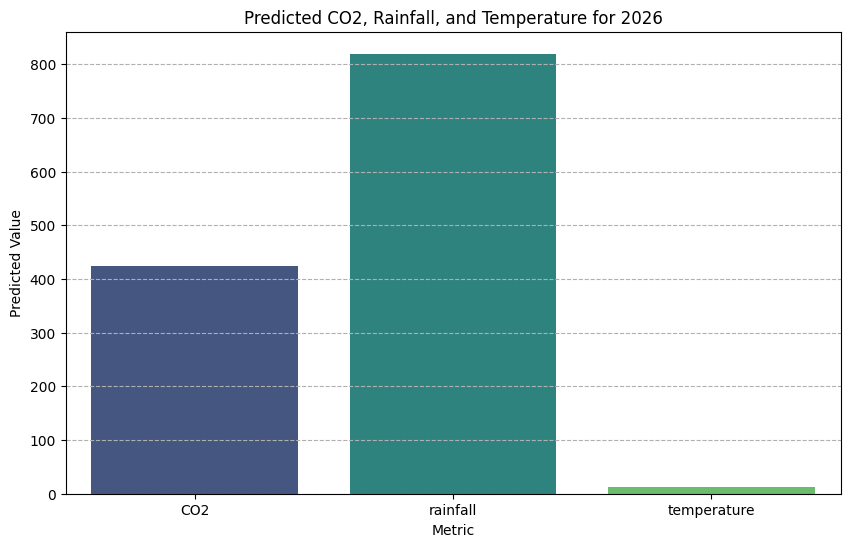

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=predictions_2026_long, palette='viridis')

# Add titles and labels for clarity
plt.title('Predicted CO2, Rainfall, and Temperature for 2026')
plt.xlabel('Metric')
plt.ylabel('Predicted Value')

# Display the plot
plt.grid(axis='y', linestyle='--')
plt.show()

# Task
Export the trained `RandomForestRegressor` model and the `StandardScaler` to disk using `joblib`.

## Export Model and Scaler

### Subtask:
Save the trained `RandomForestRegressor` model and the `StandardScaler` to disk using a library like `joblib` or `pickle`.


**Reasoning**:
I need to import the `joblib` library to save the trained model and scaler to disk. This is the first step according to the instructions.



In [23]:
import joblib

print("joblib imported successfully.")

joblib imported successfully.


**Reasoning**:
I need to save the trained RandomForestRegressor model and the fitted StandardScaler object to disk using `joblib.dump()` as specified in the instructions.



In [26]:
import joblib

# Save the trained RandomForestRegressor model
joblib.dump(model, 'random_forest_model.joblib')
print("RandomForestRegressor model saved as 'random_forest_model.joblib'")

# Save the fitted StandardScaler object
joblib.dump(scaler, 'scaler.joblib')
print("StandardScaler saved as 'scaler.joblib'")

RandomForestRegressor model saved as 'random_forest_model.joblib'
StandardScaler saved as 'scaler.joblib'


## Create a Backend API

### Subtask:
Develop a simple web API using a Python framework like Flask or FastAPI. This API will have an endpoint that accepts new input data (e.g., 'year' and 'humidity'), loads the exported model and scaler, preprocesses the input, makes predictions, and returns the results.


**Reasoning**:
The subtask requires setting up a Flask API. The first step is to import the necessary libraries, including `Flask`, `request` for handling HTTP requests, `joblib` for loading the saved model and scaler, and `pandas` for data manipulation.



In [27]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd

print("Required libraries imported successfully.")

Required libraries imported successfully.


**Reasoning**:
Now that the necessary libraries are imported, I need to initialize the Flask application as specified in the instructions.



In [28]:
app = Flask(__name__)

print("Flask app initialized.")

Flask app initialized.


**Reasoning**:
Now, I need to load the saved `RandomForestRegressor` model and `StandardScaler` object using `joblib.load()` as per the instructions.



In [30]:
import joblib

# Load the trained model
model = joblib.load('random_forest_model.joblib')
print("RandomForestRegressor model loaded successfully.")

# Load the fitted scaler
scaler = joblib.load('scaler.joblib')
print("StandardScaler loaded successfully.")

RandomForestRegressor model loaded successfully.
StandardScaler loaded successfully.


**Reasoning**:
I need to define an API endpoint (`/predict`) that accepts POST requests, extracts 'year' and 'humidity' from the incoming JSON data, preprocesses it using the loaded scaler, makes predictions with the loaded model, and returns the results as a JSON response, as specified in the instructions.



In [33]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd

# Re-initialize the Flask app to ensure routes are not overwritten on re-execution
app = Flask(__name__)

# Load the trained model
model = joblib.load('random_forest_model.joblib')

# Load the fitted scaler
scaler = joblib.load('scaler.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    if not request.json:
        return jsonify({'error': 'Invalid input, request must be JSON'}), 400

    # Extract year and humidity from request data
    year = request.json.get('year')
    humidity = request.json.get('humidity')

    if year is None or humidity is None:
        return jsonify({'error': 'Missing \'year\' or \'humidity\' in request'}), 400

    try:
        # Create a pandas DataFrame from the input
        input_df = pd.DataFrame({
            'year': [int(year)],
            'humidity': [float(humidity)]
        })

        # Scale the input data using the loaded scaler
        input_scaled = scaler.transform(input_df)

        # Make predictions using the loaded model
        predictions = model.predict(input_scaled)

        # Convert predictions to a suitable format for JSON response
        # The model predicts CO2, rainfall, and temperature in that order
        prediction_labels = ['CO2', 'rainfall', 'temperature']
        prediction_dict = {label: float(value) for label, value in zip(prediction_labels, predictions[0])}

        return jsonify(prediction_dict)

    except Exception as e:
        return jsonify({'error': str(e)}), 500

print("'/predict' endpoint defined and model/scaler loaded.")

'/predict' endpoint defined and model/scaler loaded.


**Reasoning**:
Now that the Flask app and its `/predict` endpoint are defined, I need to add the conditional block to run the Flask application when the script is executed, as per the final instruction in the subtask.



In [ ]:
if __name__ == '__main__':
    # The host='0.0.0.0' makes the server publicly accessible, which is useful for Colab
    # The port can be adjusted if needed, e.g., port=5001
    app.run(host='0.0.0.0', port=5000)

print("Flask app run command added. The app will start when this cell is executed.")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
